In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import make_moons, load_iris

In [43]:
X_moons, y_moons = make_moons(n_samples= 200, noise = 0.2, random_state= 42)

df_moons = pd.DataFrame(X_moons, columns=["Feature 1", "Feature 2"])
df_moons["Class"] = y_moons

df_moons.head()

,Feature 1,Feature 2,Class
0,-1.106897,0.042293,0
1,0.956800,0.456750,0
2,0.733516,0.584617,0
3,1.111407,-0.309214,1
4,0.209082,0.000657,1


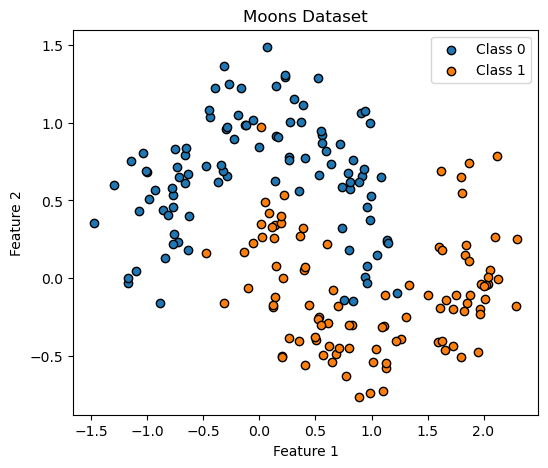

In [44]:
plt.figure(figsize=(6,5))

for class_value in np.unique(y_moons):
    plt.scatter(
        X_moons[y_moons == class_value, 0],
        X_moons[y_moons == class_value, 1],
        label=f"Class {class_value}",
        edgecolors='black'
    )
plt.title("Moons Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()

plt.savefig("figure1_moons_dataset.png")
plt.show()

In [9]:
#Iris dataset
iris = load_iris()
X_iris = iris.data[:, :2]
y_iris = iris.target

mask = y_iris !=2
X_iris = X_iris[mask]
y_iris = y_iris[mask]

df_iris = pd.DataFrame(X_iris, columns= ["Sepal Length", "Sepal Width"])
df_iris["Class"] = y_iris

df_iris.head()

,Sepal Length,Sepal Width,Class
0,5.1,3.5,0
1,4.9,3.0,0
2,4.7,3.2,0
3,4.6,3.1,0
4,5.0,3.6,0


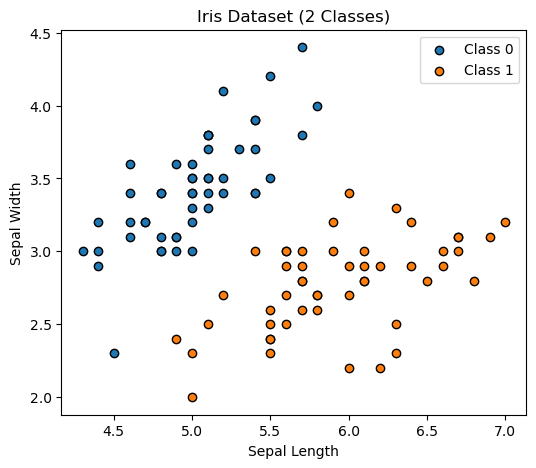

In [45]:
plt.figure(figsize=(6,5))

for class_value in np.unique(y_iris):
    plt.scatter(
        X_iris[y_iris == class_value, 0],
        X_iris[y_iris == class_value, 1],
        label=f"Class {class_value}",
        edgecolors='black'
    )
plt.title("Iris Dataset (2 Classes)")
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.legend()

plt.savefig("figure2_iris_dataset.png")
plt.show()

In [12]:
#SVM models
models = (
    svm.SVC(kernel='linear', C=1),
    svm.SVC(kernel='poly', degree=3, C=1),
    svm.SVC(kernel='rbf', gamma=1, C=1)
)

titles = (
    "Linear Kernel",
    "Polynomial Kernel",
    "RBF Kernel"
)

In [14]:
for model in models:
    model.fit(X_moons, y_moons)

In [27]:
#Decision boundary function
def plot_decision_boundary(ax, model, X, y):
    x_min, x_max = X[:,0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:,1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # colour blind friendly background 
    ax.contourf(xx, yy, Z, cmap='viridis', alpha=0.3)

    #plotting points with labels 
    for class_value in np.unique(y):
        ax.scatter(
            X[y == class_value, 0],
            X[y == class_value, 1],
            label=f"Class {class_value}",
            edgecolors='black'
        )

    ax.legend()
    


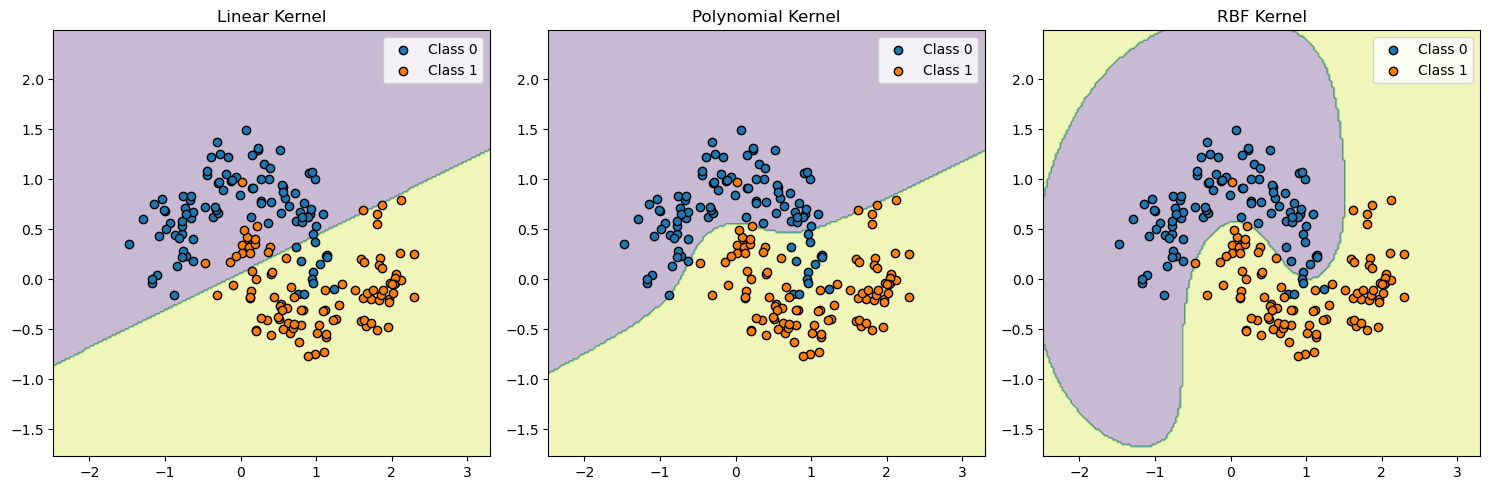

In [47]:
#Kernel comparison (Moons)
fig,  axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, model, title in zip(axes, models, titles):
    plot_decision_boundary(ax, model, X_moons, y_moons)
    ax.set_title(title)

plt.tight_layout()
plt.savefig("figure3_kernels_moons.png")
plt.show()

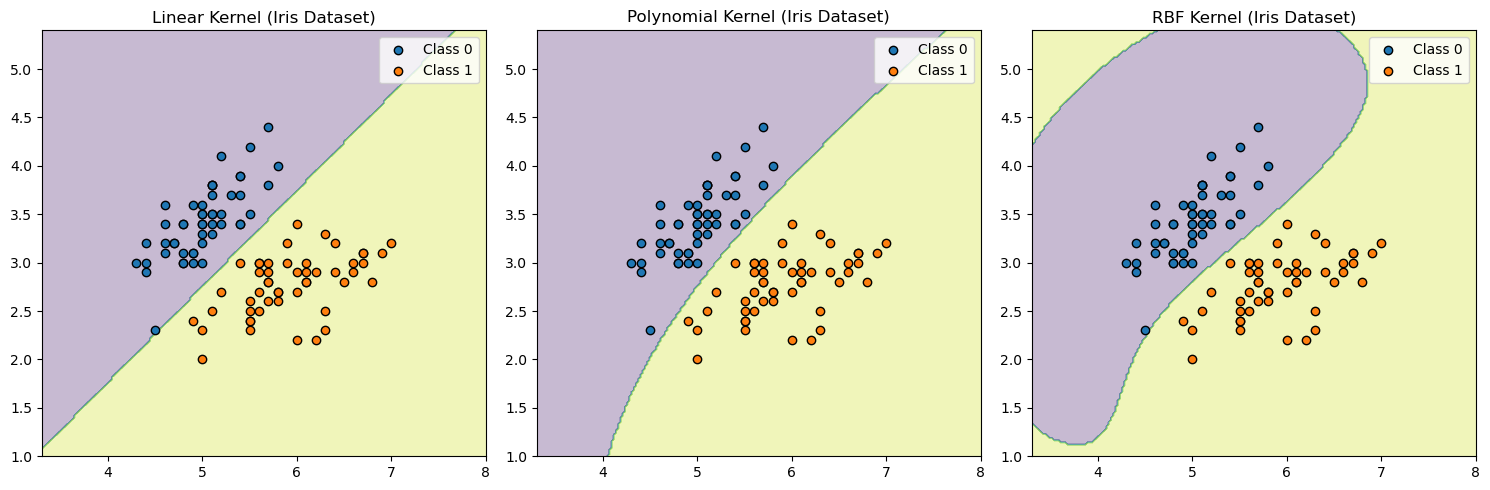

In [48]:
"""
Applying different SVM kernels to a real-world dataset(Iris). this allows us to compare 
how kernel choice affects performance on structured, near-linearly seperable data 

"""
#Defining SVM models with differnt kernels 
models_iris = (
    svm.SVC(kernel='linear', C=1),
    svm.SVC(kernel='poly', degree=3, C=1),
    svm.SVC(kernel='rbf', gamma=1, C=1)
)
titles = (
    "Linear Kernel",
    "Polynomial Kernel",
    "RBF Kernel"
)

#Training the model using the iris dataset

for model in models_iris:
    model.fit(X_iris, y_iris)

#creating a figure with 3 subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

#loop through each model and plot its decision boundary
for ax, model, title in zip(axes, models_iris, titles):

    #plotting decision boundary using the reusable function
    plot_decision_boundary(ax, model, X_iris, y_iris)

    ax.set_title(title + " (Iris Dataset)")

#Adjusting layout to prevent overlapping of plots 
plt.tight_layout()
plt.savefig("figure4_kernels_iris.png")
plt.show()

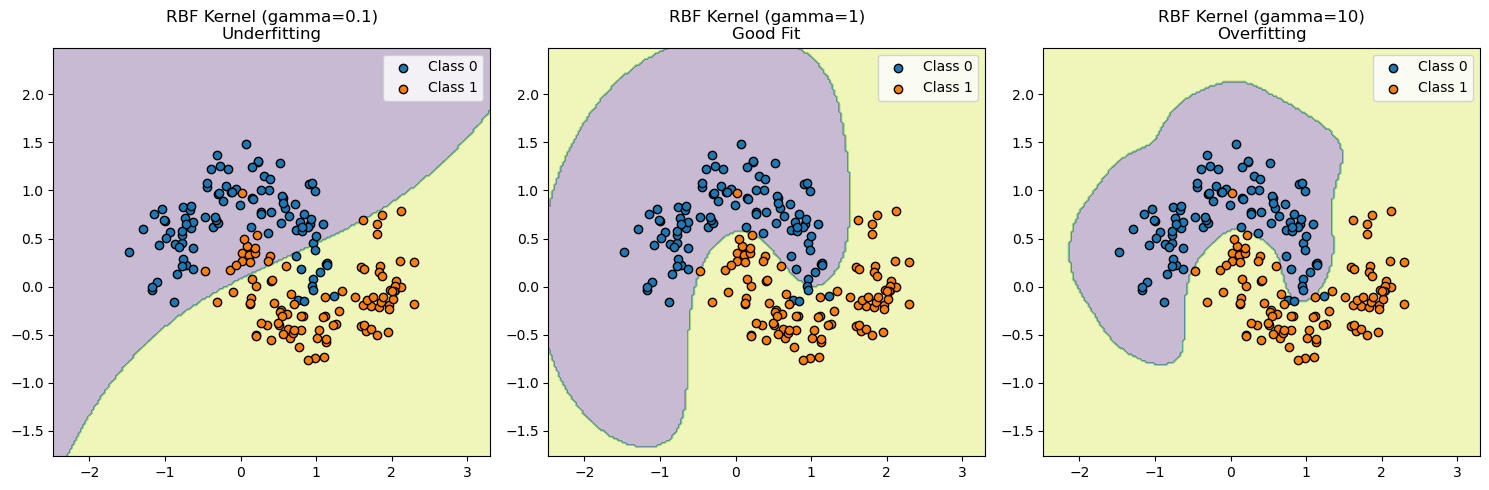

In [49]:
#Exploring the effect of gamma on RBF kernel performance 

gammas = [0.1, 1, 10]

gamma_labels = ["Underfitting", "Good Fit", "Overfitting"]

#creating SVM models using RBF kernels with different gamma values
models_gamma = [svm.SVC(kernel='rbf', gamma=g, C=1) for g in gammas]

#training each model on the make_moons dataset
for model in models_gamma:
    model.fit(X_moons, y_moons)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, model, gamma, label in zip(axes, models_gamma, gammas, gamma_labels):
    
    plot_decision_boundary(ax, model, X_moons, y_moons)

    #set title showing gamma value
    ax.set_title(f"RBF Kernel (gamma={gamma})\n{label}")

plt.tight_layout()
plt.savefig("figure5_gamma_analysis.png")
plt.show()